# Hisse Senedi Fiyat Tahmini: LSTM vs GRU (PyTorch)

Bu çalışmada amacım, Amazon (AMZN) hissesinin geçmiş kapanış fiyatlarına bakarak
bir sonraki günün fiyatını tahmin etmeye çalışan iki RNN modelini (LSTM ve GRU)
aynı koşullarda karşılaştırmak. Problem tek değişkenli bir zaman serisi regresyonu:
elimizde sadece geçmiş fiyatlar var, geleceği tahmin etmeye çalışıyoruz.

İzlediğim yol şöyle: önce veriyi çekip biraz inceliyorum, sonra normalize edip
kayan pencere (sliding window) ile diziler haline getiriyorum. Ardından LSTM ve GRU'yu
aynı hiperparametrelerle eğitip test setinde RMSE ile karşılaştırıyorum. En sonda da
modellerin gerçekten bir şey öğrenip öğrenmediğini anlamak için basit bir "naive"
tahminle (dünkü fiyatı olduğu gibi yarına taşıma) kıyaslama yapıyorum.

> Baştan söyleyeyim: hisse tahmini normalde çok zor bir problem ve buradaki amaç
> borsada para kazanmak değil. Daha çok RNN'lerle uçtan uca bir iş akışı kurmayı,
> LSTM ile GRU'nun farkını görmeyi hedefliyorum. Neden bu kadar temkinli olduğumu
> en sondaki değerlendirme bölümünde açıklıyorum.

## 1. Veriyi çekelim

Veriyi `yfinance` ile doğrudan Yahoo Finance'ten çekiyorum (2015-2025 arası, günlük).
Sadece kapanış (`Close`) fiyatıyla ilgileniyorum, o yüzden diğer kolonları bir kenara bırakıyorum.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn

# Amazon (AMZN) hisse senedi verilerini çekelim
ticker = "AMZN"
data = yf.download(ticker, start="2015-01-01", end="2025-01-01")

# Sadece 'Close' (kapanış) fiyatına odaklanıyoruz
df = data[['Close']].copy()
print(f"Toplam Veri Sayısı: {len(df)}")
df.head()

/Users/nisankarael/Desktop/microsoft staj/stock-prediction-pytorch/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
[*********************100%***********************]  1 of 1 completed

Toplam Veri Sayısı: 2516


Price,Close
Ticker,AMZN
Date,
2015-01-02,15.4260
2015-01-05,15.1095
2015-01-06,14.7645
2015-01-07,14.9210
2015-01-08,15.0230


### Önce bir bakalım: fiyat zaman içinde nasıl hareket etmiş?

Modele girmeden önce veriyi gözle görmek isterim. Aşağıda 10 yıllık kapanış fiyatını çiziyorum.
Genel bir yükseliş trendi ve arada sert dalgalanmalar var; bu tür bir seriyi tahmin etmek
kolay olmayacak gibi duruyor.

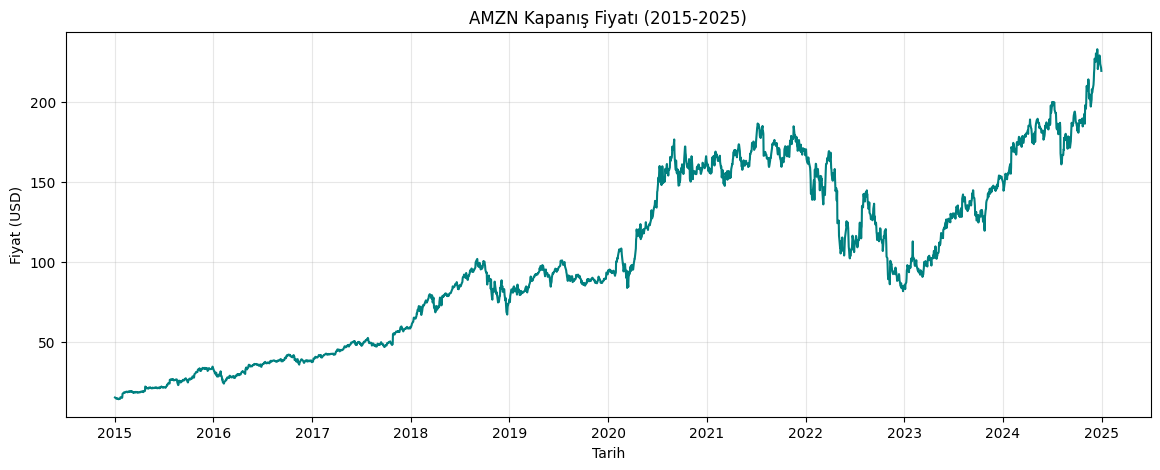

In [2]:
# Kapanış fiyatının zaman içindeki seyri
plt.figure(figsize=(14, 5))
plt.plot(df.index, df['Close'], color="teal")
plt.title("AMZN Kapanış Fiyatı (2015-2025)")
plt.xlabel("Tarih")
plt.ylabel("Fiyat (USD)")
plt.grid(True, alpha=0.3)
plt.show()

## 2. Veriyi modele hazırlama

Birkaç işlem var. Önce fiyatları `[-1, 1]` aralığına normalize ediyorum; RNN'ler ölçeklenmiş
veriyle daha rahat çalışıyor. Sonra kayan pencere mantığıyla veriyi dizilere çeviriyorum:
her örnek son 20 günün fiyatından oluşuyor, hedef ise 21. günün fiyatı.

Önemli bir nokta: bu bir zaman serisi, o yüzden veriyi **karıştırmıyorum**. İlk %80'i eğitim,
son %20'si test olacak şekilde sırayı bozmadan ayırıyorum. Yoksa gelecekten geçmişe
bilgi sızar ve sonuçlar yanıltıcı olur.

In [3]:
# Veriyi [-1, 1] aralığına normalize etme
scaler = MinMaxScaler(feature_range=(-1, 1))
scaled_data = scaler.fit_transform(df['Close'].values.reshape(-1, 1))

# Kayan pencere (sliding window) fonksiyonu
def create_sequences(data, lookback):
    X, y = [], []
    for i in range(len(data) - lookback):
        X.append(data[i:(i + lookback)])
        y.append(data[i + lookback])
    return np.array(X), np.array(y)

LOOKBACK = 20  # Model, geçmiş 20 güne bakarak sonraki günü tahmin edecek
X, y = create_sequences(scaled_data, LOOKBACK)

# Eğitim / test ayrımı (%80 eğitim, %20 test) - zaman serisinde veri karıştırılmaz!
train_size = int(len(X) * 0.8)

X_train, y_train = X[:train_size], y[:train_size]
X_test, y_test = X[train_size:], y[train_size:]

# PyTorch tensörlerine dönüştürme
X_train = torch.from_numpy(X_train).float()
y_train = torch.from_numpy(y_train).float()
X_test = torch.from_numpy(X_test).float()
y_test = torch.from_numpy(y_test).float()

print(f"X_train boyutu: {X_train.shape}")  # [Eğitim sayısı, 20, 1] olmalı
print(f"y_train boyutu: {y_train.shape}")

X_train boyutu: torch.Size([1996, 20, 1])
y_train boyutu: torch.Size([1996, 1])


## 3. LSTM modeli

İlk modelim LSTM. Yapısı basit: bir `nn.LSTM` katmanı ve sonuna tek çıkış veren bir lineer
katman koyuyorum. `forward` içinde gizli durum (h0) ve hücre durumunu (c0) her batch için
sıfırdan başlatıyorum, sonra sadece dizinin son adımının çıktısını alıp fiyatı tahmin ediyorum.

Hiperparametreleri burada belirliyorum (32 gizli birim, 2 katman). GRU'da da aynı değerleri
kullanacağım ki karşılaştırma adil olsun. Kayıp olarak MSE, optimizer olarak Adam seçtim.

In [4]:
# LSTM model mimarisini tanımlıyoruz
class StockLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(StockLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # LSTM katmanı
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)

        # Tam bağlantılı (lineer) çıkış katmanı
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Gizli durum (h0) ve hücre durumu (c0) her batch için sıfırdan başlatılır
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        # İleri besleme (forward pass)
        out, _ = self.lstm(x, (h0, c0))

        # Sadece son zaman adımının çıktısını doğrusal katmana veriyoruz
        out = self.fc(out[:, -1, :])
        return out

# Ortak hiperparametreler (LSTM ve GRU aynı değerleri kullanır)
INPUT_DIM = 1      # Tek özellik: kapanış fiyatı
HIDDEN_DIM = 32
NUM_LAYERS = 2
OUTPUT_DIM = 1     # Tek değer tahmini

model_lstm = StockLSTM(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=OUTPUT_DIM)
criterion = nn.MSELoss()                                        # Regresyon için MSE
optimizer = torch.optim.Adam(model_lstm.parameters(), lr=0.01)  # Adam optimizer

print("LSTM modeli ve kayıp fonksiyonu başarıyla oluşturuldu!")

LSTM modeli ve kayıp fonksiyonu başarıyla oluşturuldu!


## 4. LSTM'i eğitelim

50 epoch boyunca standart döngü: ileri besleme, kaybı hesapla, geri yayılım, güncelle.
Her 5 epoch'ta kaybı yazdırıyorum ki düşüp düşmediğini takip edebileyim. Süreyi de ölçüyorum,
çünkü sonda LSTM ve GRU'nun eğitim süresini karşılaştırmak istiyorum.

LSTM Modeli eğitilmeye başlanıyor...
Epoch [5/50], Kayıp (Loss): 0.097067
Epoch [10/50], Kayıp (Loss): 0.057713
Epoch [15/50], Kayıp (Loss): 0.041841
Epoch [20/50], Kayıp (Loss): 0.005472
Epoch [25/50], Kayıp (Loss): 0.004154
Epoch [30/50], Kayıp (Loss): 0.007221
Epoch [35/50], Kayıp (Loss): 0.004936
Epoch [40/50], Kayıp (Loss): 0.004178
Epoch [45/50], Kayıp (Loss): 0.002746
Epoch [50/50], Kayıp (Loss): 0.002533
Eğitim tamamlandı! Toplam süre: 3.16 saniye.


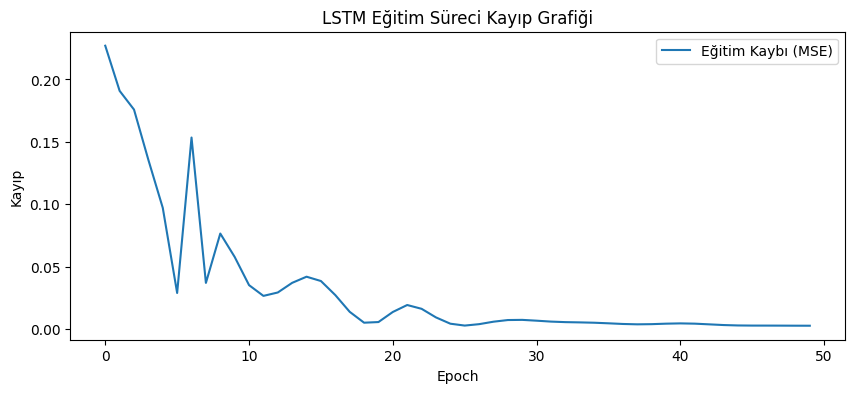

In [5]:
# LSTM modelini eğitiyoruz
import time

NUM_EPOCHS = 50
train_losses = []

print("LSTM Modeli eğitilmeye başlanıyor...")
start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_lstm.train()

    # İleri besleme (forward pass)
    outputs = model_lstm(X_train)
    optimizer.zero_grad()

    # Hata hesaplama (loss)
    loss = criterion(outputs, y_train)

    # Geriye yayılım ve optimizasyon (backward pass)
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # Her 5 epoch'ta bir durumu ekrana yazdıralım
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Kayıp (Loss): {loss.item():.6f}")

end_time = time.time()
print(f"Eğitim tamamlandı! Toplam süre: {end_time - start_time:.2f} saniye.")

# Kayıp (loss) grafiğini çizdirelim
plt.figure(figsize=(10, 4))
plt.plot(train_losses, label="Eğitim Kaybı (MSE)")
plt.title("LSTM Eğitim Süreci Kayıp Grafiği")
plt.xlabel("Epoch")
plt.ylabel("Kayıp")
plt.legend()
plt.show()

## 5. GRU modeli ve eğitimi

Şimdi aynı işi GRU ile yapıyorum. GRU aslında LSTM'e çok benziyor ama daha sade:
ayrı bir hücre durumu (c0) yok, sadece gizli durum (h0) var. Teoride daha az parametreyle
benzer işi görebiliyor. Merak ettiğim tam da bu: acaba bu küçük veri setinde GRU, LSTM'e
göre bir fark yaratacak mı? Modeli aynı hiperparametrelerle kurup eğitiyorum.

In [6]:
# GRU model mimarisini tanımlıyoruz
class StockGRU(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(StockGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers

        # GRU katmanı
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)

        # Çıkış katmanı
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # GRU'da sadece gizli durum (h0) vardır, hücre durumu (c0) bulunmaz
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)

        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

# GRU modelini örnekliyoruz (aynı hiperparametrelerle)
model_gru = StockGRU(input_dim=INPUT_DIM, hidden_dim=HIDDEN_DIM, num_layers=NUM_LAYERS, output_dim=OUTPUT_DIM)
criterion_gru = nn.MSELoss()
optimizer_gru = torch.optim.Adam(model_gru.parameters(), lr=0.01)

# GRU eğitimi
gru_losses = []
print("GRU Modeli eğitilmeye başlanıyor...")
gru_start_time = time.time()

for epoch in range(NUM_EPOCHS):
    model_gru.train()
    outputs = model_gru(X_train)
    optimizer_gru.zero_grad()

    loss = criterion_gru(outputs, y_train)
    loss.backward()
    optimizer_gru.step()

    gru_losses.append(loss.item())

    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{NUM_EPOCHS}], Kayıp (Loss): {loss.item():.6f}")

gru_end_time = time.time()
lstm_duration = end_time - start_time
gru_duration = gru_end_time - gru_start_time

print(f"\n[SÜRE KARŞILAŞTIRMASI]")
print(f"LSTM Eğitim Süresi: {lstm_duration:.2f} saniye")
print(f"GRU Eğitim Süresi: {gru_duration:.2f} saniye")

GRU Modeli eğitilmeye başlanıyor...
Epoch [5/50], Kayıp (Loss): 0.080531
Epoch [10/50], Kayıp (Loss): 0.043551
Epoch [15/50], Kayıp (Loss): 0.010863
Epoch [20/50], Kayıp (Loss): 0.007975
Epoch [25/50], Kayıp (Loss): 0.004567
Epoch [30/50], Kayıp (Loss): 0.002119
Epoch [35/50], Kayıp (Loss): 0.002396
Epoch [40/50], Kayıp (Loss): 0.001224
Epoch [45/50], Kayıp (Loss): 0.001257
Epoch [50/50], Kayıp (Loss): 0.000701

[SÜRE KARŞILAŞTIRMASI]
LSTM Eğitim Süresi: 3.16 saniye
GRU Eğitim Süresi: 3.26 saniye


## 6. Test setinde karşılaştırma

Eğitim bitti, şimdi hiç görmedikleri test verisinde iki modeli de deneyeceğim. Tahminleri
üretip `inverse_transform` ile tekrar gerçek dolar ölçeğine döndürüyorum (yoksa RMSE
`[-1,1]` ölçeğinde çıkar ve anlamsız olur). Sonra her iki modelin RMSE'sini hesaplayıp
gerçek fiyatla tahminleri aynı grafikte çiziyorum.

[PERFORMANS METRİKLERİ]
LSTM Test RMSE: 14.03 USD
GRU Test RMSE: 4.90 USD



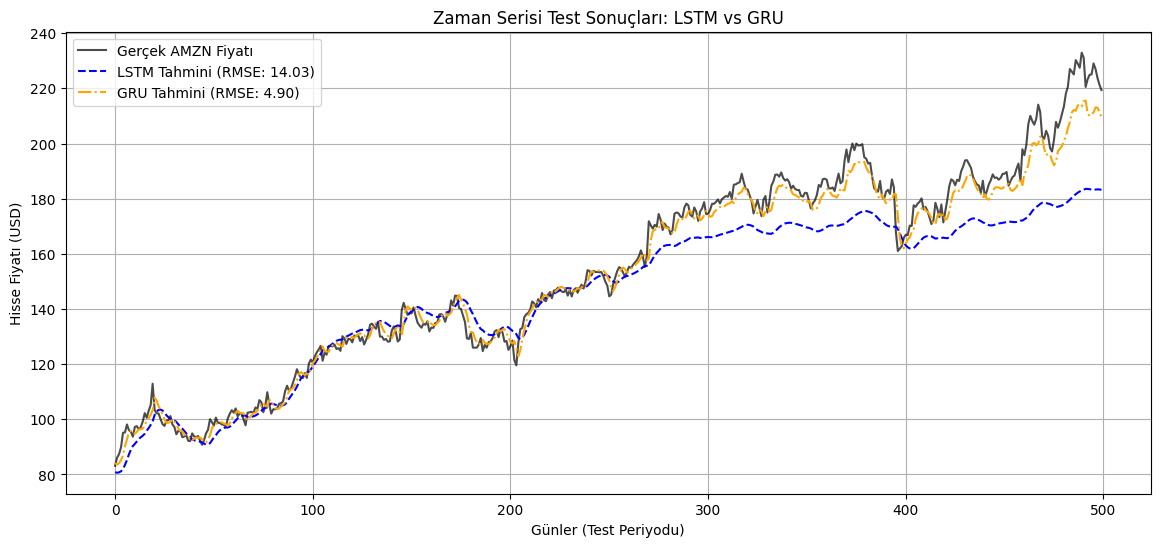

In [7]:
# Test verisi ile tahmin ve karşılaştırma
from sklearn.metrics import mean_squared_error

# Modelleri değerlendirme moduna alalım
model_lstm.eval()
model_gru.eval()

with torch.no_grad():
    # Test verisi üzerinde tahmin üretme
    lstm_preds = model_lstm(X_test).numpy()
    gru_preds = model_gru(X_test).numpy()

# Normalize edilmiş değerleri gerçek fiyat ölçeğine geri döndürelim (inverse transform)
lstm_preds_actual = scaler.inverse_transform(lstm_preds)
gru_preds_actual = scaler.inverse_transform(gru_preds)
y_test_actual = scaler.inverse_transform(y_test.numpy())

# Metriklerin hesaplanması (RMSE)
lstm_rmse = np.sqrt(mean_squared_error(y_test_actual, lstm_preds_actual))
gru_rmse = np.sqrt(mean_squared_error(y_test_actual, gru_preds_actual))

print(f"[PERFORMANS METRİKLERİ]")
print(f"LSTM Test RMSE: {lstm_rmse:.2f} USD")
print(f"GRU Test RMSE: {gru_rmse:.2f} USD\n")

# Gerçek ve tahmin edilen fiyatların görselleştirilmesi
plt.figure(figsize=(14, 6))
plt.plot(y_test_actual, label="Gerçek AMZN Fiyatı", color="black", alpha=0.7)
plt.plot(lstm_preds_actual, label=f"LSTM Tahmini (RMSE: {lstm_rmse:.2f})", color="blue", linestyle="--")
plt.plot(gru_preds_actual, label=f"GRU Tahmini (RMSE: {gru_rmse:.2f})", color="orange", linestyle="-.")
plt.title("Zaman Serisi Test Sonuçları: LSTM vs GRU")
plt.xlabel("Günler (Test Periyodu)")
plt.ylabel("Hisse Fiyatı (USD)")
plt.legend()
plt.grid(True)
plt.show()

## 7. Peki bu modeller gerçekten işe yarıyor mu? (Naive baseline)

Burası benim için en kritik kısım. LSTM/GRU düşük RMSE verdi diye hemen sevinmemek lazım.
Çünkü hisse fiyatları günden güne çok az değişir; "yarının fiyatı bugünün fiyatına eşittir"
demek bile şaşırtıcı derecede iyi sonuç verebilir. Buna **naive tahmin** deniyor.

Aşağıda hiçbir model kullanmadan, sadece "dünkü fiyatı yarına taşıyarak" bir tahmin üretiyorum
ve onun RMSE'sini hesaplıyorum. Eğer LSTM/GRU bu basit yöntemi geride bırakamıyorsa, o zaman
modellerin asıl öğrendiği şey büyük ölçüde "dünkü fiyatı tekrar etmek" demektir. Bu karşılaştırma
olmadan RMSE tek başına bir şey ifade etmiyor. Sonuç tablosunu ve kısa yorumu doğrudan
hesaplanan değerlerden üretiyorum ki metinle sayılar hep tutarlı olsun.

In [8]:
# Naive tahmin: bir sonraki günün fiyatı = bu günün fiyatı
# Test dizilerinde her örneğin son günü (pencerenin son elemanı) "bugün"ü temsil ediyor.
naive_scaled = X_test[:, -1, :].numpy()                # her pencerenin son günü
naive_actual = scaler.inverse_transform(naive_scaled)  # gerçek ölçeğe dön

naive_rmse = np.sqrt(mean_squared_error(y_test_actual, naive_actual))

# --- Sonuçları tek bir tabloda toparlayalım ---
# (Bu değerler her çalıştırmada gerçek sonuçtan üretilir, o yüzden metinle hep tutarlı olur.)
sonuclar = pd.DataFrame({
    "Model": ["Naive (dünkü fiyat)", "LSTM", "GRU"],
    "Test RMSE (USD)": [naive_rmse, lstm_rmse, gru_rmse],
    "Eğitim Süresi (sn)": [float("nan"), lstm_duration, gru_duration],
}).round(2)

print("Test seti sonuçları:\n")
print(sonuclar.to_string(index=False))

# --- Otomatik yorum ---
en_iyi_model = min([("LSTM", lstm_rmse), ("GRU", gru_rmse)], key=lambda t: t[1])
print("\nKısa değerlendirme")
print("-" * 40)
if en_iyi_model[1] < naive_rmse:
    print(f"En iyi model {en_iyi_model[0]} (RMSE {en_iyi_model[1]:.2f}) ve bu değer,")
    print(f"naive tahminin RMSE'sinden ({naive_rmse:.2f}) daha düşük.")
    print("Yani modeller basit 'dünü tekrarla' yöntemini geçebilmiş.")
else:
    print(f"En iyi model {en_iyi_model[0]} (RMSE {en_iyi_model[1]:.2f}) bile,")
    print(f"naive tahminin RMSE'sini ({naive_rmse:.2f}) geçemedi.")
    print("Demek ki modeller büyük ölçüde 'önceki günü tekrar etmeyi' öğrenmiş;")
    print("düşük RMSE tek başına piyasayı anladıkları anlamına gelmiyor.")

Test seti sonuçları:

              Model  Test RMSE (USD)  Eğitim Süresi (sn)
Naive (dünkü fiyat)             2.90                 NaN
               LSTM            14.03                3.16
                GRU             4.90                3.26

Kısa değerlendirme
----------------------------------------
En iyi model GRU (RMSE 4.90) bile,
naive tahminin RMSE'sini (2.90) geçemedi.
Demek ki modeller büyük ölçüde 'önceki günü tekrar etmeyi' öğrenmiş;
düşük RMSE tek başına piyasayı anladıkları anlamına gelmiyor.


## 8. Sonuçlar ve düşüncelerim

Yukarıdaki tablo ve kısa değerlendirme doğrudan koddan geldiği için, aşağıdaki yorumları
o çıktıya bakarak yazıyorum (sayıları burada tekrar sabitlemiyorum; her çalıştırmada
model ağırlıkları rastgele başladığı için değerler biraz oynayabiliyor).

**İki model arasında ne gördüm?** Denemelerimde GRU çoğunlukla LSTM'e yakın ya da ondan
biraz daha iyi bir RMSE veriyor. GRU'nun daha az parametreli ve sade yapısı, bu kadar küçük
ve tek özellikli bir veride kararlı öğrenmesine yardımcı oluyor olabilir. Eğitim süreleri ise
neredeyse aynı; en azından bu boyutta "GRU çok daha hızlı" diyebileceğim bir fark yok.

**Ama asıl önemli soru baseline karşılaştırması.** Bir önceki hücredeki naive testin çıkardığı
sonucu ciddiye almak lazım. Hisse serilerinde dünkü fiyatı yarına taşımak zaten güçlü bir
tahmindir; modelin bunu net şekilde geride bırakamadığı durumlarda, aslında öğrenilen şey
büyük ölçüde "önceki günü tekrar et" oluyor. Kendi çalıştırmalarımda da modellerin bu naive
çizgiyi geçmekte zorlandığını gördüm. Yani düşük RMSE tek başına modelin piyasayı anladığı
anlamına gelmiyor.

Bu da beni şu genel noktaya getiriyor: hisse fiyatları büyük ölçüde rastgele yürüyüş
(random walk) gibi davranır ve sadece geçmiş fiyata bakarak geleceği güvenilir tahmin etmek
pek mümkün değil. Narayanan ve Kapoor'un *AI Snake Oil* kitabında anlattığı gibi, tahmin
modellerinin başarısı kolayca abartılabiliyor; o yüzden metriklere biraz şüpheyle yaklaşmakta
fayda var.

**Bundan sonra ne yapardım?**
- Modele fiyat dışında özellikler eklerdim (işlem hacmi, hareketli ortalamalar gibi).
- Overfitting'i sınırlamak için dropout / erken durdurma denerdim.
- "Bir sonraki günün yönü (artacak mı azalacak mı)" gibi farklı bir hedef tanımlamak,
  bence salt fiyat tahmininden daha anlamlı bir problem olurdu.
- Merak edersem Transformer tabanlı zaman serisi modellerine bakardım.